# Lesson 8 — Binomial & Poisson — counting events

*Part 1 · Lesson 8 of 20  ·  data: US Births 2014 · USGS earthquakes*

**←** [Lesson 7: Random variables, expectation & variance](07-random-variables.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  [Lesson 9: The normal distribution & the empirical rule](09-normal-distribution.ipynb) **→**

**Same idea, another way:**  [Another dataset →](08-binomial-poisson~another-dataset.ipynb)  ·  [The code behind it →](08-binomial-poisson~the-code.ipynb)

Last lesson we turned random outcomes into numbers. Now we meet the two most useful *counting* models in all of statistics: the **Binomial** (how many successes in a fixed number of tries) and the **Poisson** (how many rare events happen in a fixed window of time). We'll build both by hand from real data — low-birthweight babies and worldwide earthquakes — and watch the textbook formulas snap perfectly onto the histograms we simulate. Then we'll see the surprising bridge between them.

Run each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()
rng = np.random.default_rng(12)  # fixed seed -> reproducible; learner can change it

# Part A data: 1000 US births in 2014.
births = sl.load_csv('births14.csv',
                     url='https://www.openintro.org/data/csv/births14.csv')
print(f'{len(births)} births loaded')
births[['weight', 'lowbirthweight', 'sex']].head()

1000 births loaded


,weight,lowbirthweight,sex
0,6.96,not low,male
1,8.86,not low,female
2,7.51,not low,female
3,6.19,not low,male
4,6.75,not low,female


## 1) The building block: a Bernoulli trial

Everything in this lesson starts with the simplest possible random thing: a single **yes/no** event. Flip a coin, roll for a six, check whether one baby is born underweight. A trial with exactly two outcomes — "success" (1) or "failure" (0) — is a **Bernoulli trial**, named after Jacob Bernoulli.

- **The math.** One number does the whole job: $p$, the probability of success. Then $P(\text{success}) = p$ and $P(\text{failure}) = 1 - p$.
- **The meaning.** $p$ is the long-run *fraction* of trials that come up "success."
- **The interpretation.** For us, "success" = a **low-birthweight** baby (under 2500 g / ~5.5 lb). It is not a happy event — "success" is just statistics jargon for "the thing we're counting."

Let's read $p$ straight off the data.

In [2]:
# Success = a low-birthweight baby. Estimate p as the observed fraction.
is_low = (births['lowbirthweight'] == 'low')
n_low = int(is_low.sum())
p = is_low.mean()
print(f"low-birthweight babies: {n_low} out of {len(births)}")
print(f"p = P(low birthweight) = {p:.3f}")

low-birthweight babies: 81 out of 1000
p = P(low birthweight) = 0.081


## 2) The Binomial distribution — successes in $n$ tries

Now stack $n$ **independent** Bernoulli trials (*independent* = one trial's result tells you nothing about the next), each with the same $p$, and count the successes. That count is a **Binomial** random variable, written $X \sim \text{Binomial}(n, p)$ — read the squiggle "$\sim$" as **"follows the … distribution"** (so: "$X$ follows a Binomial distribution with settings $n$ and $p$").

Picture a random group of **$n = 30$ births**. How many will be low-birthweight? It could be 0, or 1, or 2, ... up to 30 — but not all answers are equally likely.

- **The math.** The probability of *exactly* $k$ successes is
$$P(X = k) = \binom{n}{k}\, p^{k}\,(1-p)^{\,n-k}.$$
The piece $p^k(1-p)^{n-k}$ is the chance of one specific pattern with $k$ successes; $\binom{n}{k} = \frac{n!}{k!\,(n-k)!}$ counts how many different patterns give $k$ successes.
- **The meaning.** It spreads a total probability of 1 across the possible counts $0,1,\dots,n$ — this list is the **PMF** (probability mass function).
- **The interpretation.** It tells us, *before we look*, how surprising any particular number of low-birthweight babies in 30 would be.

Two summary numbers fall out of the formula:

$$\text{mean} = np, \qquad \text{variance} = np(1-p).$$

In [3]:
n = 30
mean_binom = n * p
var_binom  = n * p * (1 - p)
print(f"Model: X ~ Binomial(n={n}, p={p:.3f})")
print(f"Theory mean     = n*p       = {mean_binom:.2f} low-birthweight babies per 30")
print(f"Theory variance = n*p*(1-p) = {var_binom:.2f}")
print(f"Theory std dev  = sqrt(var) = {np.sqrt(var_binom):.2f}")

Model: X ~ Binomial(n=30, p=0.081)
Theory mean     = n*p       = 2.43 low-birthweight babies per 30
Theory variance = n*p*(1-p) = 2.23
Theory std dev  = sqrt(var) = 1.49


## 3) Simulate it — don't just believe the formula

Here is the heart of "by seeing it happen." Instead of trusting the formula, we'll *run the experiment* thousands of times: draw a random group of 30 babies, count the low-birthweight ones, and repeat. Pile the counts into a histogram and the shape of the Binomial appears on its own.

The tinkerable knobs are at the top of the cell.

In [4]:
n = 30                # babies per group
n_groups = 20000      # how many random groups to simulate
# Each group: 30 independent yes/no draws, "success" with probability p.
draws  = rng.random((n_groups, n)) < p     # True = low birthweight
counts = draws.sum(axis=1)                  # successes per group of 30

print(f"Simulated {n_groups:,} groups of {n} births.")
print(f"Simulated mean     = {counts.mean():.2f}   (theory n*p       = {n*p:.2f})")
print(f"Simulated variance = {counts.var():.2f}   (theory n*p*(1-p) = {n*p*(1-p):.2f})")

Simulated 20,000 groups of 30 births.
Simulated mean     = 2.43   (theory n*p       = 2.43)
Simulated variance = 2.19   (theory n*p*(1-p) = 2.23)


**Read those two lines.** The simulated mean and variance land right on the formulas $np$ and $np(1-p)$ — we never plugged the formulas in; the experiment produced them. Now let's overlay the exact PMF on the histogram of simulated counts. *(The bars are scaled to **probabilities** — their heights sum to 1 — so they line up directly with the formula's red dots, instead of showing raw counts in the thousands.)*

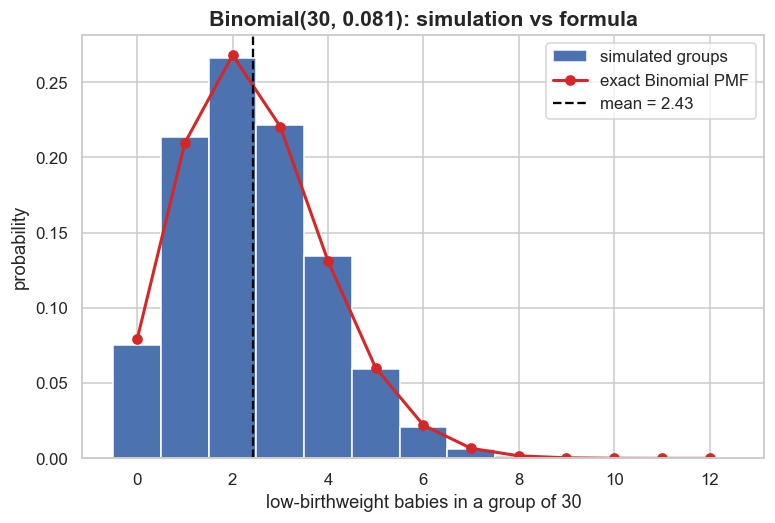

P(exactly 0 low-birthweight in 30) = 0.079
P(2 or fewer)                      = 0.557
P(5 or more)                       = 0.091


In [5]:
k = np.arange(0, 13)                         # plausible counts: 0..12
pmf = stats.binom.pmf(k, n, p)               # exact Binomial probabilities

fig, ax = plt.subplots()
ax.hist(counts, bins=np.arange(-0.5, 13.5, 1), density=True,
        color='#4c72b0', edgecolor='white', label='simulated groups')
ax.plot(k, pmf, 'o-', color='#d62728', lw=2, label='exact Binomial PMF')
ax.axvline(n * p, color='black', ls='--', lw=1.5, label=f'mean = {n*p:.2f}')
ax.set_xlabel('low-birthweight babies in a group of 30')
ax.set_ylabel('probability')
ax.set_title('Binomial(30, 0.081): simulation vs formula')
ax.legend(); plt.show()

print(f"P(exactly 0 low-birthweight in 30) = {stats.binom.pmf(0, n, p):.3f}")
print(f"P(2 or fewer)                      = {stats.binom.cdf(2, n, p):.3f}")
print(f"P(5 or more)                       = {stats.binom.sf(4, n, p):.3f}")

**The interpretation.** The red dots sit on top of the blue bars: the formula and the experiment agree. In a random group of 30 births we'd most often see **2** low-birthweight babies, would not be shocked by 0 or 4, and seeing **5 or more** is genuinely uncommon (a few percent). That last number is exactly the kind of "is this surprising?" judgment that statistics is built to make.

### A sanity check you already trust: a fair coin

To convince yourself the Binomial isn't special to birth data, set $p = 0.5$ and flip **10 coins**. The shape becomes the familiar symmetric mound centered on 5 heads.

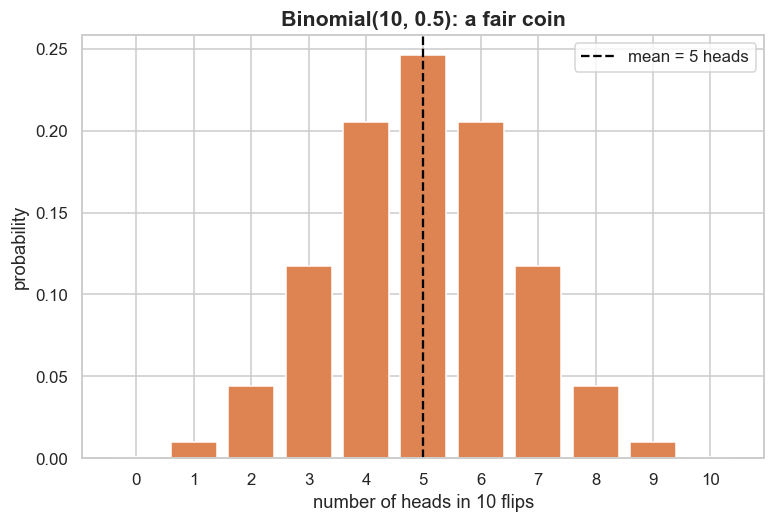

P(exactly 5 heads) = 0.246


In [6]:
n_coins, p_coin = 10, 0.5
k = np.arange(0, n_coins + 1)
pmf_coin = stats.binom.pmf(k, n_coins, p_coin)

fig, ax = plt.subplots()
ax.bar(k, pmf_coin, color='#dd8452', edgecolor='white')
ax.axvline(n_coins * p_coin, color='black', ls='--', lw=1.5,
           label=f'mean = {n_coins*p_coin:.0f} heads')
ax.set_xlabel('number of heads in 10 flips')
ax.set_ylabel('probability')
ax.set_title('Binomial(10, 0.5): a fair coin')
ax.set_xticks(k); ax.legend(); plt.show()
print(f"P(exactly 5 heads) = {stats.binom.pmf(5, n_coins, p_coin):.3f}")

## 4) The Poisson distribution — rare events per interval

The Binomial needs a fixed number of trials $n$. But many real questions have **no obvious $n$**: how many earthquakes *today*? How many emails *this hour*? There were countless moments when a quake *could* have struck, each with a tiny probability. For "lots of chances, each rare," we use the **Poisson** distribution, written $X \sim \text{Poisson}(\lambda)$.

- **The math.** With a single rate $\lambda$ (the average number of events per interval),
$$P(X = k) = \frac{e^{-\lambda}\,\lambda^{k}}{k!}, \qquad k = 0, 1, 2, \dots$$
- **The meaning.** $\lambda$ is the *typical count per interval*. The Poisson has one famous fingerprint:
$$\text{mean} = \lambda = \text{variance}.$$
The spread equals the average. If a real count's mean and variance are roughly equal, that's a strong hint a Poisson fits.
- **The interpretation.** It answers "how many in one chunk of time?" when events are independent and arrive at a steady average rate.

Let's count real earthquakes. We'll load every magnitude-4.5+ quake worldwide in **June 2024** and tally how many happened each day.

In [7]:
# Part B data: M4.5+ earthquakes worldwide, June 2024 (USGS).
quakes = sl.load_csv(
    'earthquakes_2024_06.csv',
    url='https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv'
        '&starttime=2024-06-01&endtime=2024-07-01&minmagnitude=4.5&orderby=time-asc')
print(f'{len(quakes)} earthquakes (M4.5+) in June 2024')

# Build DAILY COUNTS: one number per calendar day in June.
day = pd.to_datetime(quakes['time']).dt.date
daily = day.value_counts().reindex(
    pd.date_range('2024-06-01', '2024-06-30').date, fill_value=0)

print(f"days observed   = {len(daily)}")
print(f"mean per day    = {daily.mean():.2f}")
print(f"variance per day= {daily.var(ddof=1):.2f}")
print(f"busiest day     = {daily.max()} quakes")

507 earthquakes (M4.5+) in June 2024
days observed   = 30
mean per day    = 16.90
variance per day= 17.20
busiest day     = 28 quakes


**Look at the Poisson fingerprint.** The mean (~16.9 quakes/day) and the variance (~17.2) are almost the same number. Nothing *forces* a dataset's mean and variance to match — plenty of real counts are far more (or less) spread out than their average — so when they line up this closely, it's a strong hint that a Poisson process is at work. Now overlay the Poisson PMF (using $\lambda$ = the observed mean) on the histogram of daily counts.

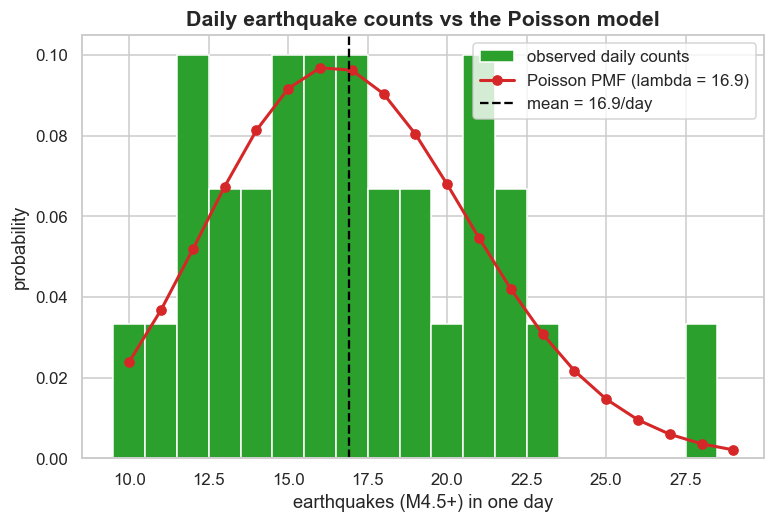

P(0 quakes on a day)  = 0.0000
P(<= 10 on a day)     = 0.051
P(>= 25 on a day)     = 0.038


In [8]:
lam = daily.mean()                           # estimate lambda from the data
k = np.arange(daily.min(), daily.max() + 2)
pmf = stats.poisson.pmf(k, mu=lam)           # exact Poisson probabilities

fig, ax = plt.subplots()
ax.hist(daily, bins=np.arange(daily.min() - 0.5, daily.max() + 1.5, 1),
        density=True, color='#2ca02c', edgecolor='white',
        label='observed daily counts')
ax.plot(k, pmf, 'o-', color='#d62728', lw=2,
        label=f'Poisson PMF (lambda = {lam:.1f})')
ax.axvline(lam, color='black', ls='--', lw=1.5, label=f'mean = {lam:.1f}/day')
ax.set_xlabel('earthquakes (M4.5+) in one day')
ax.set_ylabel('probability')
ax.set_title('Daily earthquake counts vs the Poisson model')
ax.legend(); plt.show()

print(f"P(0 quakes on a day)  = {stats.poisson.pmf(0, lam):.4f}")
print(f"P(<= 10 on a day)     = {stats.poisson.cdf(10, lam):.3f}")
print(f"P(>= 25 on a day)     = {stats.poisson.sf(24, lam):.3f}")

**The interpretation.** With only 30 days the histogram is bumpy, but the red Poisson curve threads right through it — a one-parameter formula captures the rhythm of the planet's seismic activity for the month. It says a quiet day with 10 or fewer M4.5+ quakes is fairly unusual, and a frantic day of 25+ is rare but not impossible. (We're describing **this month's data**; a different month or magnitude cutoff would have its own $\lambda$.)

## 5) The bridge: Binomial becomes Poisson

These two models look unrelated, but they're secretly the same idea. Imagine slicing a day into a *huge* number $n$ of tiny instants, each a Bernoulli trial with a *tiny* chance $p$ of a quake. That's a Binomial — but with $n$ enormous and $p$ minuscule. As $n \to \infty$ and $p \to 0$ while the product $\lambda = np$ stays fixed and moderate, the Binomial PMF **turns into** the Poisson PMF.

- **The math.** $\text{Binomial}(n, p) \to \text{Poisson}(\lambda)$ as $n\to\infty$, $p\to 0$, with $np = \lambda$.
- **The meaning.** Poisson is the "many trials, each rare" limit of the Binomial — which is exactly why it models rare events with no obvious $n$.

Let's overlay $\text{Binomial}(1000, 0.017)$ on $\text{Poisson}(17)$ and watch them nearly coincide.

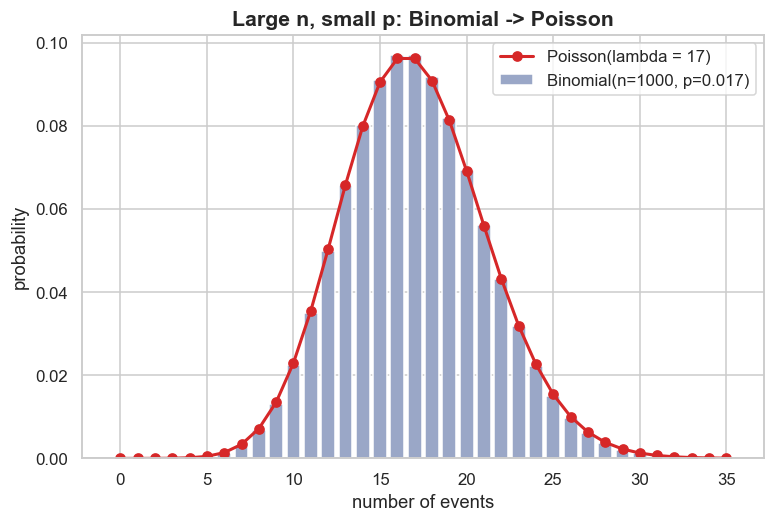

Largest difference between the two PMFs = 0.0008  (essentially identical)


In [9]:
n_big, p_small = 1000, 0.017
lam = n_big * p_small                         # = 17
k = np.arange(0, 36)

fig, ax = plt.subplots()
ax.bar(k, stats.binom.pmf(k, n_big, p_small), color='#9aa7c7',
       edgecolor='white', label=f'Binomial(n={n_big}, p={p_small})')
ax.plot(k, stats.poisson.pmf(k, mu=lam), 'o-', color='#d62728', lw=2,
        label=f'Poisson(lambda = {lam:.0f})')
ax.set_xlabel('number of events')
ax.set_ylabel('probability')
ax.set_title('Large n, small p: Binomial -> Poisson')
ax.legend(); plt.show()

# How close are they? Largest gap across all counts.
gap = np.abs(stats.binom.pmf(k, n_big, p_small) - stats.poisson.pmf(k, mu=lam)).max()
print(f"Largest difference between the two PMFs = {gap:.4f}  (essentially identical)")

**One sentence of meaning.** When $n$ is large and $p$ is small with $np$ moderate, "successes out of $n$" and "rare events per interval" are the *same distribution* — so the Poisson is just the Binomial's natural shortcut for rare things.

## Now you try

Predict first, then change one knob and re-run:

1. In the simulation cell (section 3), set `n_groups = 200` instead of `20000`. Will the histogram match the red PMF better or worse? Re-run and see how the simulated mean/variance drift from $np$ and $np(1-p)$.
2. In the fair-coin cell, raise `n_coins` to `100`. Where does the mound center now, and does its shape start to look like a bell curve? (That's a preview of Lesson 9.)
3. In the bridge cell (section 5), change `n_big, p_small` to `100, 0.17` (still $np = 17$). The product is unchanged but $p$ is bigger — does the Binomial still hug the Poisson, or does the gap grow? What does that tell you about *how small* $p$ needs to be?

## What you learned

- **Bernoulli trial:** one yes/no event with success probability $p$ — the atom every count is built from.
- **Binomial** $X\sim\text{Binomial}(n,p)$ counts successes in $n$ independent trials; $P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}$, with **mean $=np$** and **variance $=np(1-p)$** — both confirmed by simulating real birth data.
- **Poisson** $X\sim\text{Poisson}(\lambda)$ counts rare events per interval; $P(X=k)=e^{-\lambda}\lambda^k/k!$, with the fingerprint **mean $=$ variance $=\lambda$** — seen in daily earthquake counts.
- A model is **believable when the simulation matches the formula** and the data's mean/variance match the model's — not just because a textbook says so.
- **Binomial $\to$ Poisson** as $n\to\infty$, $p\to 0$ with $np=\lambda$: the two counting models are one idea viewed from two angles.

---

**← Previous:** [Lesson 7: Random variables, expectation & variance](07-random-variables.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Next →:** [Lesson 9: The normal distribution & the empirical rule](09-normal-distribution.ipynb)

**Same idea, another way:**  [Another dataset →](08-binomial-poisson~another-dataset.ipynb)  ·  [The code behind it →](08-binomial-poisson~the-code.ipynb)